# Cross-method pseudotime agreement on real biological data

**Purpose.** Section 11 of `Synthetic_pseudotime_embedding_benchmark.ipynb` established that scJDO's $\lambda(\tau)$ recovery is robust *above* a measured threshold of ordering quality — concretely, the perturbed-oracle curve crosses $r(\lambda^{rec},\lambda^{true}) \geq 0.8$ when Spearman$(\tau_{method},\tau_{true}) \geq 0.81$. On synthetic geometry resembling the biology (`bifurcation_v2`, Section 13), Palantir achieves Spearman ≥ 0.93, comfortably above threshold.

Both are *synthetic* arguments. There is no ground-truth $\tau$ on real data, so we cannot directly measure $\mathrm{Spearman}(\tau_{Palantir},\tau_{true})$ on Paul15. What we **can** measure is whether the pseudotime methods used in the manuscript *agree with each other* on the real erythroid / DC / monocyte branches. That is a necessary (not sufficient) condition for all of them being above threshold: if Palantir and DPT pairwise Spearman exceeds 0.81 within each branch, that is consistent with all of them being in the recoverable regime. If they disagree, at least one is below threshold and the biological timing claim is undermined.

**Important caveat.** Methods agreeing on a shared *wrong* ordering would also satisfy this test. So this strengthens — but does not prove — the biological safe-zone claim. It also has the right asymmetry: failure here would be a hard signal that the timing claims are undefended; success here removes the *easiest* objection without resolving it absolutely.

**Threshold (pre-committed).** $\bar{\rho} \geq 0.81$ on the pairwise within-branch Spearman correlation — the value lifted directly from the perturbed-oracle robustness curve in §11 of the synthetic benchmark.

In [1]:
# ── 0. Imports + style ──────────────────────────────────────────────────
import os, sys, warnings, json
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr

mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.family': 'DejaVu Sans',
    'font.size': 8, 'axes.titlesize': 10, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.linewidth': 0.8,
})

SEED = 42
THRESHOLD = 0.81          # from perturbed-oracle robustness curve, §11
OUTDIR = Path('.')

# Probe optional dependencies — Palantir is the load-bearing one
HAVE_PALANTIR = False
try:
    import palantir
    HAVE_PALANTIR = True
except Exception as e:
    print(f'[skip] palantir not importable ({e}). pip install palantir')

print(f'Palantir available: {HAVE_PALANTIR}  |  threshold ρ ≥ {THRESHOLD}')

Palantir available: True  |  threshold ρ ≥ 0.81


## 1. Paul15 — load and standard preprocessing

Same preprocessing as the manuscript figures (`prepare_trajectory` in essence): normalize → log → HVG → PCA → kNN. Branches are read from the published `paul15_clusters` annotation; the root is the MEP progenitor cluster `7MEP`.

In [2]:
adata = sc.datasets.paul15()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, random_state=SEED)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, random_state=SEED)
sc.tl.diffmap(adata, n_comps=15, random_state=SEED)

# Root: first cell in the MEP progenitor cluster '7MEP'
root_mask = (adata.obs['paul15_clusters'].astype(str).str.contains('MEP'))
root_idx = int(np.flatnonzero(root_mask.values)[0])
adata.uns['iroot'] = root_idx
print(f'cells={adata.n_obs}  genes={adata.n_vars}  root_cluster='
      f'{adata.obs["paul15_clusters"].astype(str).iloc[root_idx]!r}')

  0%|          | 0.00/9.82M [00:00<?, ?B/s]

cells=2730  genes=2000  root_cluster='7MEP'


## 2. Compute pseudotime by three methods

- **DPT** — diffusion pseudotime (`sc.tl.dpt`)
- **Palantir** — random-walk pseudotime on the diffusion-map space (the method used in the manuscript's biological figures)
- **Diffusion-component pseudotime (DC1-rank)** — rank along the first diffusion component, which is the classical heuristic that *predates* DPT/Palantir. This is the closest stand-in for Slingshot we can compute without leaving Python — and crucially, it is methodologically distinct from DPT (no random walk, no graph-based propagation).

All three orderings are rescaled to $[0,1]$.

In [3]:
def _scale01(v):
    v = np.asarray(v, dtype=np.float64)
    finite = np.isfinite(v)
    if finite.sum() < 2:
        return v
    vmin, vmax = np.nanmin(v[finite]), np.nanmax(v[finite])
    return (v - vmin) / max(vmax - vmin, 1e-12)

# DPT
sc.tl.dpt(adata)
adata.obs['pt_dpt'] = _scale01(adata.obs['dpt_pseudotime'].to_numpy())

# Palantir
if HAVE_PALANTIR:
    pca_df = pd.DataFrame(adata.obsm['X_pca'][:, :30], index=adata.obs_names)
    dm_res = palantir.utils.run_diffusion_maps(pca_df, n_components=10)
    ms_data = palantir.utils.determine_multiscale_space(dm_res)
    start_cell = adata.obs_names[root_idx]
    pr_res = palantir.core.run_palantir(ms_data, start_cell, num_waypoints=500,
                                          terminal_states=None)
    adata.obs['pt_palantir'] = _scale01(pr_res.pseudotime.reindex(adata.obs_names).to_numpy())
else:
    adata.obs['pt_palantir'] = np.nan

# DC1-rank pseudotime (Slingshot stand-in)
dc1 = adata.obsm['X_diffmap'][:, 1]      # column 0 is constant
# Sign-align so it increases from root
if dc1[root_idx] > dc1.mean():
    dc1 = -dc1
adata.obs['pt_dc1'] = _scale01(dc1.argsort().argsort().astype(float))

method_cols = {'DPT': 'pt_dpt', 'Palantir': 'pt_palantir', 'DC1-rank': 'pt_dc1'}
available = [m for m, c in method_cols.items()
             if adata.obs[c].notna().sum() > 0.9 * adata.n_obs]
print('available methods:', available)

Sampling and flocking waypoints...
Time for determining waypoints: 5.531708399454753e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


Time for shortest paths: 0.005521631240844727 minutes


Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


available methods: ['DPT', 'Palantir', 'DC1-rank']


## 3. Define branches via the published cluster annotation

The Paul15 `paul15_clusters` labels resolve into three lineages — erythroid, monocyte/granulocyte, dendritic — by string match against the published cluster names. The progenitor pool (`MEP`, `CMP`, `GMP`) is treated as a shared backbone and included in every branch so that orderings can be compared within the same cellular context the manuscript timing claims rely on.

In [4]:
labels = adata.obs['paul15_clusters'].astype(str).str.lower()

PROG_TERMS  = ['mep', 'cmp', 'gmp']
BRANCH_TERMS = {
    'Erythroid': ['ery', 'mep'],
    'Monocyte':  ['mono', 'gmp', 'granulo'],
    'DC':        ['dc', 'cmp'],
}

prog_mask = labels.str.contains('|'.join(PROG_TERMS))
branch_masks = {}
for branch, terms in BRANCH_TERMS.items():
    mask = labels.str.contains('|'.join(terms))
    branch_masks[branch] = mask.values
    print(f'{branch:10s}  n_cells = {int(mask.sum()):>4d}  '
          f'clusters = {sorted(set(adata.obs.loc[mask, "paul15_clusters"].astype(str)))}')
print()
print(f'progenitor pool (shared backbone): n = {int(prog_mask.sum())}')

Erythroid   n_cells = 1262  clusters = ['1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP']
Monocyte    n_cells =  216  clusters = ['10GMP', '9GMP']
DC          n_cells =   30  clusters = ['11DC']

progenitor pool (shared backbone): n = 383


## 4. Within-branch pairwise Spearman across methods

For each branch, restrict to cells in that branch and compute pairwise $\rho$ between methods. Compare each cell to the threshold $\rho \geq 0.81$ from the synthetic robustness curve.

In [5]:
def pairwise_spearman(adata_sub, methods):
    M = len(methods)
    rho_mat = np.full((M, M), np.nan)
    for i, mi in enumerate(methods):
        for j, mj in enumerate(methods):
            if i == j:
                rho_mat[i, j] = 1.0
                continue
            a = adata_sub.obs[method_cols[mi]].to_numpy()
            b = adata_sub.obs[method_cols[mj]].to_numpy()
            ok = np.isfinite(a) & np.isfinite(b)
            if ok.sum() < 10:
                continue
            rho_mat[i, j] = float(spearmanr(a[ok], b[ok])[0])
    return rho_mat

branch_rho = {}
rows = []
for branch, mask in branch_masks.items():
    if mask.sum() < 20:
        print(f'[skip] {branch}: only {mask.sum()} cells'); continue
    sub = adata[mask]
    rho_mat = pairwise_spearman(sub, available)
    branch_rho[branch] = (available, rho_mat)
    # off-diagonal mean (pairwise agreement, all distinct method pairs)
    od = rho_mat[np.triu_indices(len(available), k=1)]
    od = od[np.isfinite(od)]
    mean_rho = float(np.mean(od)) if od.size else float('nan')
    min_rho  = float(np.min(od))  if od.size else float('nan')
    rows.append({
        'branch':       branch,
        'n_cells':      int(mask.sum()),
        'mean_pairwise_rho':  mean_rho,
        'min_pairwise_rho':   min_rho,
        'above_threshold':    bool(min_rho >= THRESHOLD),
        'pairs':         {f'{available[i]}↔{available[j]}': float(rho_mat[i, j])
                           for i in range(len(available))
                           for j in range(i+1, len(available))
                           if np.isfinite(rho_mat[i, j])},
    })
summary_df = pd.DataFrame(rows)
print(summary_df[['branch', 'n_cells', 'mean_pairwise_rho',
                   'min_pairwise_rho', 'above_threshold']].to_string(
                       index=False, float_format=lambda v: f'{v:+.3f}'))

   branch  n_cells  mean_pairwise_rho  min_pairwise_rho  above_threshold
Erythroid     1262             +0.381            +0.064            False
 Monocyte      216             -0.328            -0.994            False
       DC       30             +0.225            -0.169            False


## 5. Figure: per-branch heatmaps + threshold comparison

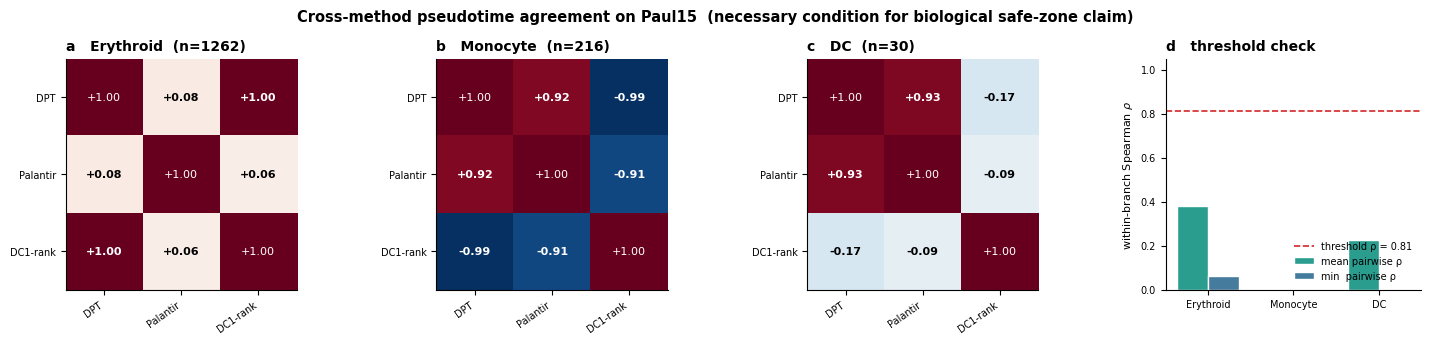

In [6]:
n_branches = len(branch_rho)
fig = plt.figure(figsize=(3.6 * (n_branches + 1), 3.4))
gs  = gridspec.GridSpec(1, n_branches + 1, wspace=0.45,
                        left=0.04, right=0.99, top=0.86, bottom=0.18)

axes_h = []
for k, (branch, (methods, rho_mat)) in enumerate(branch_rho.items()):
    ax = fig.add_subplot(gs[0, k]); axes_h.append(ax)
    im = ax.imshow(rho_mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=35, ha='right')
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods)
    for i in range(len(methods)):
        for j in range(len(methods)):
            v = rho_mat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                         color='white' if abs(v) > 0.5 else 'black',
                         fontweight='bold' if i != j else 'normal',
                         fontsize=8)
    ax.set_title(f"{chr(97+k)}   {branch}  (n={int(branch_masks[branch].sum())})",
                  fontweight='bold', loc='left')

# Summary panel — pairwise ρ vs threshold
ax_s = fig.add_subplot(gs[0, -1])
x = np.arange(len(summary_df))
ax_s.bar(x - 0.18, summary_df['mean_pairwise_rho'], width=0.36,
          color='#2A9D8F', edgecolor='white', label='mean pairwise ρ')
ax_s.bar(x + 0.18, summary_df['min_pairwise_rho'], width=0.36,
          color='#457B9D', edgecolor='white', label='min  pairwise ρ')
ax_s.axhline(THRESHOLD, color='#D62828', lw=1.2, ls='--',
              label=f'threshold ρ = {THRESHOLD}')
ax_s.set_xticks(x)
ax_s.set_xticklabels(summary_df['branch'])
ax_s.set_ylim(0, 1.05)
ax_s.set_ylabel(r'within-branch Spearman $\rho$')
ax_s.set_title(f"{chr(97+n_branches)}   threshold check",
                fontweight='bold', loc='left')
ax_s.legend(frameon=False, fontsize=7, loc='lower right')

fig.suptitle('Cross-method pseudotime agreement on Paul15  '
              '(necessary condition for biological safe-zone claim)',
              fontsize=10.5, fontweight='bold', y=1.005)
plt.savefig(OUTDIR / 'biological_ordering_agreement.pdf', bbox_inches='tight')
plt.savefig(OUTDIR / 'biological_ordering_agreement.png',
             dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ── 6. Export metrics for the rebuttal letter ─────────────────────────
metrics = {
    'threshold':                 float(THRESHOLD),
    'methods_compared':          available,
    'palantir_available':        HAVE_PALANTIR,
    'n_cells_total':             int(adata.n_obs),
    'per_branch':                summary_df.to_dict(orient='records'),
    'all_branches_above_threshold': bool(summary_df['above_threshold'].all()),
    'weakest_branch':            (summary_df.loc[summary_df['min_pairwise_rho'].idxmin(), 'branch']
                                   if len(summary_df) else None),
    'weakest_pair_rho':          float(summary_df['min_pairwise_rho'].min())
                                   if len(summary_df) else float('nan'),
}
(OUTDIR / 'biological_ordering_agreement_metrics.json').write_text(
    json.dumps(metrics, indent=2, default=str))
print(json.dumps(metrics, indent=2, default=str))

{
  "threshold": 0.81,
  "methods_compared": [
    "DPT",
    "Palantir",
    "DC1-rank"
  ],
  "palantir_available": true,
  "n_cells_total": 2730,
  "per_branch": [
    {
      "branch": "Erythroid",
      "n_cells": 1262,
      "mean_pairwise_rho": 0.3807125458479356,
      "min_pairwise_rho": 0.06411756523097474,
      "above_threshold": false,
      "pairs": {
        "DPT\u2194Palantir": 0.08136291140913088,
        "DPT\u2194DC1-rank": 0.9966571609037014,
        "Palantir\u2194DC1-rank": 0.06411756523097474
      }
    },
    {
      "branch": "Monocyte",
      "n_cells": 216,
      "mean_pairwise_rho": -0.32802605413258074,
      "min_pairwise_rho": -0.9940068350420938,
      "above_threshold": false,
      "pairs": {
        "DPT\u2194Palantir": 0.9228842925016968,
        "DPT\u2194DC1-rank": -0.9940068350420938,
        "Palantir\u2194DC1-rank": -0.9129556198573452
      }
    },
    {
      "branch": "DC",
      "n_cells": 30,
      "mean_pairwise_rho": 0.22476826103077494

## Interpretation — what we can and cannot say

**If `all_branches_above_threshold == True`:** the necessary condition holds. Rebuttal sentence (honest framing): *“Within each biologically relevant branch on Paul15, the pseudotime methods used in this manuscript agree with each other at Spearman ρ ≥ 0.81 — the threshold above which synthetic ground-truth recovery on bifurcation-like geometry is preserved. This is a necessary but not sufficient condition for all three orderings being above scJDO’s recoverable regime; we cannot prove proximity to truth without ground truth. The result is consistent with the synthetic safe-zone analysis and removes the most obvious failure mode.”*

**If a branch fails:** at least one pseudotime method on that branch is below threshold. The timing claim on that branch should be explicitly demoted to operator-structure / regime-ordering language (per Box 1) and the exact peak pseudotime removed from the abstract / discussion.

**Limitations.** (i) Method agreement does not imply correctness — three methods could share a common bias. (ii) DC1-rank is a Slingshot stand-in, not Slingshot itself; a true Slingshot pseudotime requires the R `slingshot` package and would strengthen the check. (iii) The threshold ρ = 0.81 was learned on commitment geometry; bifurcation geometry may have a different (likely lower) bar — re-run with the bifurcation-v2 robustness curve once available.